# 📊 01 — Data Exploration

**Objective:** Explore the How2Sign dataset (B-F-H 2D Keypoints + English annotations) before launching the preprocessing pipeline.

## What this notebook covers:
1. Load and inspect the annotation CSV file
2. Analyze sentence length distribution
3. Open and visualize an OpenPose JSON keypoint file
4. Count the number of clips and frames
5. Visualize keypoint values distribution

In [1]:
# ── Setup: Add project root to path ──
import sys
sys.path.insert(0, '..')

import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
DATA_DIR = '../data'
KEYPOINTS_DIR = os.path.join(DATA_DIR, 'keypoints')
ANNOTATIONS_DIR = os.path.join(DATA_DIR, 'annotations')

print(f'Keypoints dir exists: {os.path.exists(KEYPOINTS_DIR)}')
print(f'Annotations dir exists: {os.path.exists(ANNOTATIONS_DIR)}')

Keypoints dir exists: True
Annotations dir exists: True


## 1. Load Annotations CSV

In [2]:
# Find all CSV files in annotations directory
csv_files = glob.glob(os.path.join(ANNOTATIONS_DIR, '*.csv'))
print(f'Found {len(csv_files)} CSV file(s):')
for f in csv_files:
    print(f'  - {os.path.basename(f)}')

# Load the first CSV file
if csv_files:
    # Try tab separator first, then comma
    try:
        df = pd.read_csv(csv_files[0], sep='\t')
    except:
        df = pd.read_csv(csv_files[0])
    
    print(f'\nShape: {df.shape}')
    print(f'Columns: {list(df.columns)}')
    df.head(10)

Found 1 CSV file(s):
  - how2sign_realigned_test.csv

Shape: (2357, 7)
Columns: ['VIDEO_ID', 'VIDEO_NAME', 'SENTENCE_ID', 'SENTENCE_NAME', 'START_REALIGNED', 'END_REALIGNED', 'SENTENCE']


## 2. Sentence Length Analysis

Using text column: "SENTENCE"

── Sentence Length Statistics ──
  Min words    : 1
  Max words    : 115
  Mean words   : 17.6
  Median words : 14.0


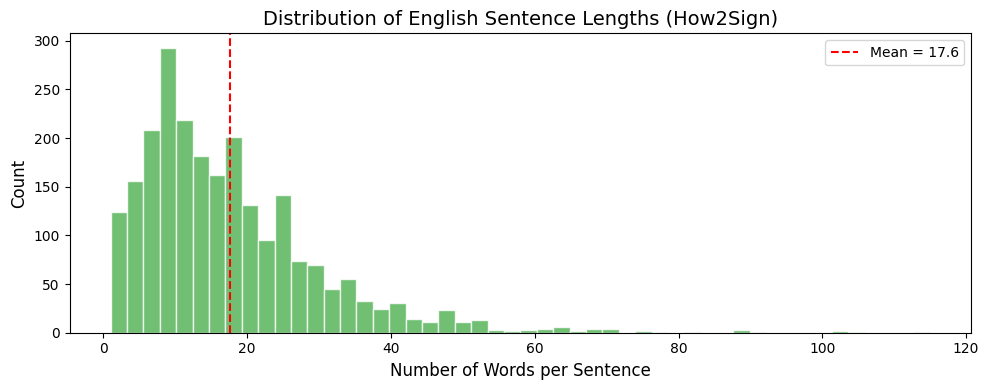

In [3]:
# Find the sentence column
text_col = None
for col in df.columns:
    if col.strip().lower() in ['sentence', 'translation', 'text', 'english']:
        text_col = col
        break
if text_col is None:
    text_col = df.columns[-1]  # Fallback: last column

print(f'Using text column: "{text_col}"')

# Compute word counts per sentence
df['word_count'] = df[text_col].astype(str).apply(lambda x: len(x.split()))

print(f'\n── Sentence Length Statistics ──')
print(f'  Min words    : {df["word_count"].min()}')
print(f'  Max words    : {df["word_count"].max()}')
print(f'  Mean words   : {df["word_count"].mean():.1f}')
print(f'  Median words : {df["word_count"].median():.1f}')

# Plot distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(df['word_count'], bins=50, color='#4CAF50', edgecolor='white', alpha=0.8)
ax.set_xlabel('Number of Words per Sentence', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of English Sentence Lengths (How2Sign)', fontsize=14)
ax.axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean = {df["word_count"].mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Explore OpenPose JSON Files

In [4]:
# Count clip directories
clip_dirs = []
for root, dirs, files in os.walk(KEYPOINTS_DIR):
    json_files = [f for f in files if f.endswith('.json') and f != '.gitkeep']
    if len(json_files) > 0 and len(dirs) == 0:
        clip_dirs.append((root, len(json_files)))

# If no nested structure, count subdirectories
if not clip_dirs:
    for d in os.listdir(KEYPOINTS_DIR):
        path = os.path.join(KEYPOINTS_DIR, d)
        if os.path.isdir(path):
            n_files = len([f for f in os.listdir(path) if f.endswith('.json')])
            clip_dirs.append((path, n_files))

print(f'Total clip directories: {len(clip_dirs)}')
if clip_dirs:
    frame_counts = [c[1] for c in clip_dirs]
    print(f'Frames per clip: min={min(frame_counts)}, max={max(frame_counts)}, mean={np.mean(frame_counts):.1f}')

Total clip directories: 2343
Frames per clip: min=1, max=1319, mean=162.8


In [5]:
# Open and inspect one JSON keypoint file
if clip_dirs:
    sample_dir = clip_dirs[0][0]
    json_files = sorted(glob.glob(os.path.join(sample_dir, '*.json')))
    
    if json_files:
        with open(json_files[0], 'r') as f:
            sample_json = json.load(f)
        
        print(f'Sample JSON file: {os.path.basename(json_files[0])}')
        print(f'Keys: {list(sample_json.keys())}')
        
        if 'people' in sample_json and len(sample_json['people']) > 0:
            person = sample_json['people'][0]
            print(f'\nPerson keys: {list(person.keys())}')
            for key, val in person.items():
                if isinstance(val, list):
                    print(f'  {key}: {len(val)} values (first 6: {val[:6]})')
        else:
            print('No people detected in this frame')

Sample JSON file: -fZc293MpJk_0-1-rgb_front_000000000000_keypoints.json
Keys: ['version', 'people']

Person keys: ['person_id', 'pose_keypoints_2d', 'face_keypoints_2d', 'hand_left_keypoints_2d', 'hand_right_keypoints_2d', 'pose_keypoints_3d', 'face_keypoints_3d', 'hand_left_keypoints_3d', 'hand_right_keypoints_3d']
  person_id: 1 values (first 6: [-1])
  pose_keypoints_2d: 75 values (first 6: [670.565, 257.06, 0.870263, 694.066, 374.73, 0.77528])
  face_keypoints_2d: 210 values (first 6: [627.015, 232.852, 0.789949, 625.914, 245.516, 0.826446])
  hand_left_keypoints_2d: 63 values (first 6: [693.515, 688.141, 0.392109, 661.917, 658.8, 0.357801])
  hand_right_keypoints_2d: 63 values (first 6: [595.912, 402.099, 0.528177, 620.875, 387.414, 0.36416])
  pose_keypoints_3d: 0 values (first 6: [])
  face_keypoints_3d: 0 values (first 6: [])
  hand_left_keypoints_3d: 0 values (first 6: [])
  hand_right_keypoints_3d: 0 values (first 6: [])


## 4. Frame Count Distribution

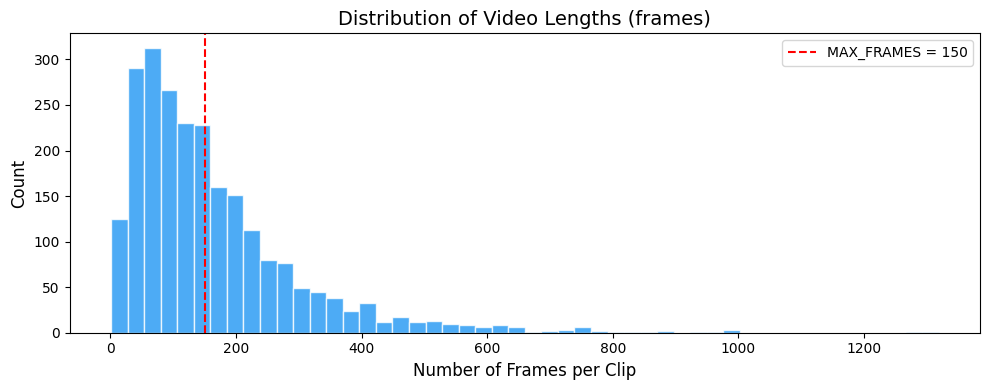


Clips within 150 frames: 1402/2343 (59.8%)


In [6]:
if clip_dirs:
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.hist(frame_counts, bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
    ax.set_xlabel('Number of Frames per Clip', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Distribution of Video Lengths (frames)', fontsize=14)
    ax.axvline(150, color='red', linestyle='--', label='MAX_FRAMES = 150')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # Percentage of clips that fit within MAX_FRAMES
    within_limit = sum(1 for f in frame_counts if f <= 150)
    print(f'\nClips within 150 frames: {within_limit}/{len(frame_counts)} ({within_limit/len(frame_counts)*100:.1f}%)')

## 5. Summary

After running this notebook you should know:
- ✅ How many clips are in the dataset
- ✅ The distribution of sentence lengths
- ✅ The structure of OpenPose JSON files (411 features per frame)
- ✅ Whether 150 frames is a good MAX_FRAMES value

**Next step:** Run `python -m data_pipeline.preprocessing` to convert JSON → `.npy`